<a href="https://colab.research.google.com/github/MudasirH-coder/Mudasir-demo/blob/main/Pama.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_excel('/content/pama.xlsx')

In [ ]:
df.head(5)

,Vehicles,Column1,Month,Year,Value,Vehicles.1,Vehicles Cleaned,Classification,Category.1
0,Honda Civic,Prod.,Jul,2007,554.0,Honda Civic,Honda Cars (Civic & City),1300cc and Above,CARS
1,Honda Civic,Prod.,Aug,2007,533.0,Honda Civic,Honda Cars (Civic & City),1300cc and Above,CARS
2,Honda Civic,Prod.,Sep,2007,405.0,Honda Civic,Honda Cars (Civic & City),1300cc and Above,CARS
3,Honda Civic,Prod.,Oct,2007,662.0,Honda Civic,Honda Cars (Civic & City),1300cc and Above,CARS
4,Honda Civic,Prod.,Nov,2007,423.0,Honda Civic,Honda Cars (Civic & City),1300cc and Above,CARS


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.isnull().sum()

,0
Vehicles,0
Column1,1
Month,0
Year,0
Value,115
Vehicles.1,630
Vehicles Cleaned,630
Classification,11270
Category.1,636


In [ ]:
df.isnull().sum().sum()

np.int64(13277)

In [ ]:
df.fillna(df.mean(numeric_only=True),inplace=True)

In [ ]:
df['Date'] = pd.to_datetime(df['Month'] + ' ' + df['Year'].astype(str))

/tmp/ipykernel_7017/3238571645.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Month'] + ' ' + df['Year'].astype(str))


**Handle outliers **

In [ ]:
Q1 = df['Value'].quantile(0.25)
Q3 = df['Value'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['Value'] >= lower_bound) & (df['Value'] <= upper_bound)]
df.describe()

,Year,Value,Date
count,15251.000000,15251.000000,15251
mean,2016.285883,523.698839,2016-10-01 18:01:34.892138240
min,2007.000000,0.000000,2007-07-01 00:00:00
25%,2012.000000,15.000000,2012-02-01 00:00:00
50%,2016.000000,159.000000,2016-11-01 00:00:00
75%,2021.000000,910.000000,2021-07-01 00:00:00
max,2025.000000,2477.000000,2025-05-01 00:00:00
std,5.308425,674.472863,NaN


A histogram is a graphical tool used in statistics to visualize the distribution of continuous numerical data

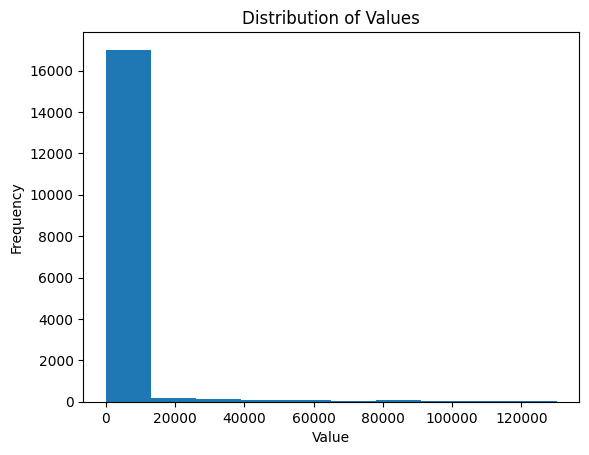

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['Value'])
plt.title('Distribution of Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

A scatter plot is a data visualization tool that uses dots to represent the values of two different numeric variables

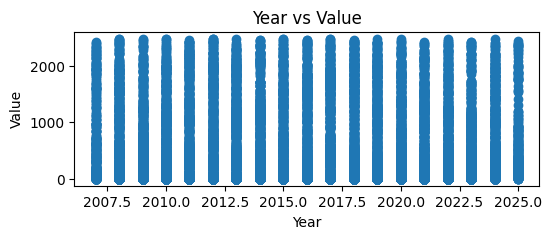

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,2))
plt.scatter(df['Year'], df['Value'])
plt.title('Year vs Value')
plt.xlabel('Year')
plt.ylabel('Value')
plt.show()

**A box plot (also known as a box-and-whisker plot) is a standardized way of displaying the distribution of numerical data based on a five-number summary.**

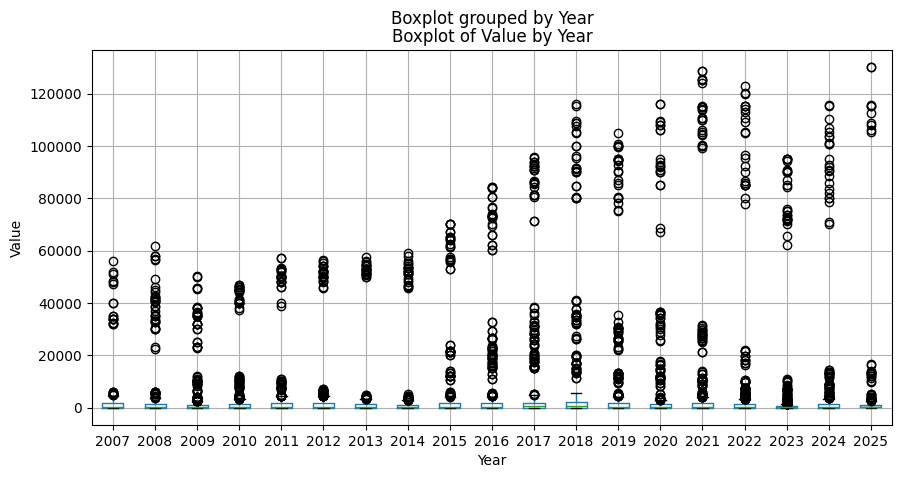

In [ ]:
df.boxplot(column='Value', by='Year', figsize=(10,5))
plt.title('Boxplot of Value by Year')
plt.xlabel('Year')
plt.ylabel('Value')
plt.show()

**Bar Chart (Category vs total Value) → Category comparison**

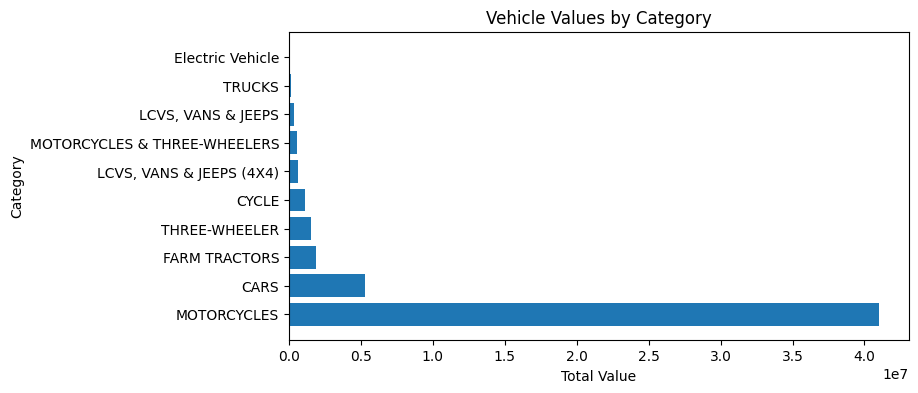

In [ ]:
import matplotlib.pyplot as plt

category = df.groupby('Category.1')['Value'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 4))

plt.barh(category.index, category.values)

plt.title('Vehicle Values by Category')
plt.xlabel('Total Value')
plt.ylabel('Category')

plt.show()